# 06 — Visualization Quickstart

Sentinel includes two visualization classes that cover the full spectrum of anomaly analysis — from score plotting to model interpretability:

| Class | Engine | Methods |
|-------|--------|---------|
| `AnomalyVisualizer` | matplotlib / Plotly | `plot_static()`, `plot_dynamic()`, `plot_score_distribution()`, `plot_features()` |
| `SHAPVisualizer` | SHAP + matplotlib | `plot_force()`, `plot_summary()`, `plot_waterfall()`, `plot_bar()`, `plot_dependence()` |

### Why visualize?

Anomaly detectors produce numeric scores and binary labels, but those numbers alone don't tell the full story. Visualization enables you to:

1. **Validate** that detected anomalies align with real events (incidents, deployments, traffic spikes)
2. **Calibrate thresholds** — by seeing the score distribution, you can adjust the cutoff between normal and anomalous
3. **Understand feature behavior** — see which features spike during anomalies
4. **Communicate results** to non-technical teams with clear, readable charts
5. **Interpret** which features contribute to each prediction (SHAP)

> **Requirements**: `pip install sentinel[viz]` (installs `plotly`, `shap`, `matplotlib`)

In [1]:
import numpy as np
import pandas as pd

np.random.seed(42)

---
## 1. Prepare Synthetic Data

We create a multivariate dataset that simulates server metrics over ~5 days at 15-minute intervals. The DataFrame includes:

- **cpu**: CPU usage percentage with a sinusoidal daily pattern
- **memory_mb**: memory consumption with its own cycle
- **error_rate**: baseline error rate around 2%
- **scores**: continuous anomaly score (higher = more anomalous)
- **anomaly**: binary label where `-1` = anomaly, `0` = normal

We inject **8 anomaly spikes** at known positions where CPU, memory, and error rate all jump simultaneously. This lets us verify that the visualizations correctly highlight the right samples and features.

In [2]:
n = 500
dates = pd.date_range('2025-01-01', periods=n, freq='15min')

# Simulate server metrics with daily patterns
cpu = 45 + 15 * np.sin(2 * np.pi * np.arange(n) / 96) + np.random.normal(0, 3, n)
memory = 2048 + 200 * np.sin(2 * np.pi * np.arange(n) / 48) + np.random.normal(0, 30, n)
error_rate = np.abs(np.random.normal(0.02, 0.01, n))

# Anomaly scores (mostly low, with spikes)
scores = np.abs(np.random.normal(0.2, 0.1, n))
anomaly_mask = np.zeros(n, dtype=int)

# Inject anomaly spikes at known positions
spike_indices = [50, 51, 120, 200, 201, 202, 350, 400]
scores[spike_indices] = np.random.uniform(0.8, 1.5, len(spike_indices))
cpu[spike_indices] += np.random.uniform(20, 40, len(spike_indices))
memory[spike_indices] += np.random.uniform(500, 1200, len(spike_indices))
error_rate[spike_indices] = np.random.uniform(0.3, 0.7, len(spike_indices))
anomaly_mask[spike_indices] = -1

anomaly_df = pd.DataFrame({
    'cpu': cpu,
    'memory_mb': memory,
    'error_rate': error_rate,
    'scores': scores,
    'anomaly': anomaly_mask,
}, index=dates)

# Define a threshold for later use
threshold = scores[anomaly_mask == 0].mean() + 2 * scores[anomaly_mask == 0].std()

print(anomaly_df.head(10))
print(f"\nTotal anomalies: {(anomaly_df['anomaly'] == -1).sum()}")
print(f"Threshold (mean + 2*std of normal scores): {threshold:.3f}")
print(f"Time range: {dates[0]} → {dates[-1]}")

                           cpu    memory_mb  error_rate    scores  anomaly
2025-01-01 00:00:00  46.490142  2075.785326    0.033994  0.277836        0
2025-01-01 00:15:00  45.566254  2131.387738    0.029246  0.144881        0
2025-01-01 00:30:00  48.900958  2057.806782    0.020596  0.118180        0
2025-01-01 00:45:00  52.495444  2141.425764    0.013531  0.199663        0
2025-01-01 01:00:00  48.179826  2128.480723    0.026982  0.182982        0
2025-01-01 01:15:00  49.119181  2155.138524    0.023935  0.154677        0
2025-01-01 01:30:00  55.477890  2171.649539    0.028952  0.269639        0
2025-01-01 01:45:00  53.936635  2180.750945    0.026352  0.295531        0
2025-01-01 02:00:00  51.091577  2222.660730    0.030496  0.208841        0
2025-01-01 02:15:00  54.961234  2207.847403    0.014648  0.347753        0

Total anomalies: 8
Threshold (mean + 2*std of normal scores): 0.394
Time range: 2025-01-01 00:00:00 → 2025-01-06 04:45:00


---
## 2. Define Incident Windows (optional)

In production environments, operations teams log **incidents** with start and end times. 
`AnomalyVisualizer` can overlay these windows on the score chart, letting you visually answer:

- Did the detector catch the incident? (red dots inside the blue band)
- Were there false positives outside incident windows?
- Did the detector anticipate the incident? (anomalies just before the band starts)

The incidents DataFrame requires three columns: `start_time`, `end_time`, and `Servicio`.

In [3]:
incidents_df = pd.DataFrame({
    'start_time': pd.to_datetime(['2025-01-01 12:00', '2025-01-03 02:00']),
    'end_time':   pd.to_datetime(['2025-01-01 14:00', '2025-01-03 05:00']),
    'Servicio': ['Service A outage', 'Service B degradation'],
})

incidents_df

,start_time,end_time,Servicio
0,2025-01-01 12:00:00,2025-01-01 14:00:00,Service A outage
1,2025-01-03 02:00:00,2025-01-03 05:00:00,Service B degradation


---
## 3. `plot_static()` — Score Timeline (matplotlib)

The static scatter plot shows anomaly scores over time:

- **Gray line**: score evolution
- **Green dots**: normal samples
- **Red dots**: anomalies (`anomaly == -1`)
- **Blue bands**: known incident windows
- **Orange dashed line**: optional threshold

### Interpreting the chart

| Pattern | Meaning |
|---------|---------|
| Red dots inside blue bands | Detector captured real incidents |
| Red dots outside blue bands | Possible false positives, or unlabeled real anomalies |
| Blue bands without red dots | Missed incidents (false negatives) |
| Threshold line above most green dots | Well-calibrated threshold |

/Users/jomaver/Desktop/Code/sentinel/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


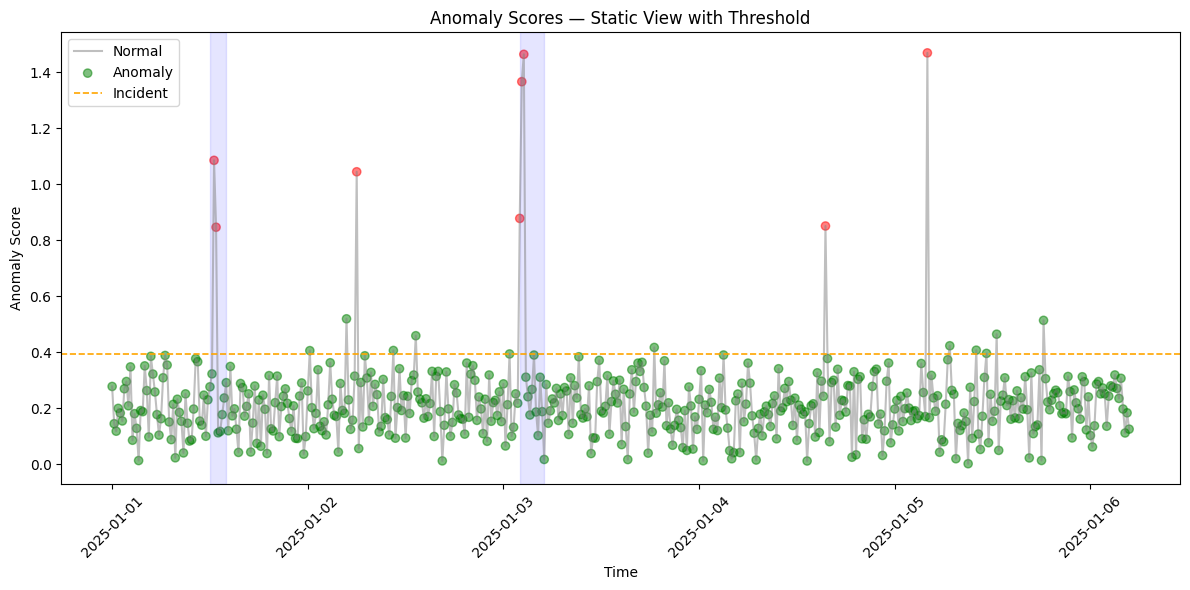

In [4]:
from sentinel.visualization import AnomalyVisualizer

viz = AnomalyVisualizer(
    anomaly_df=anomaly_df,
    incidents_df=incidents_df,
    score_col='scores',
    anomaly_col='anomaly',
)

# Static plot with threshold line
viz.plot_static(
    threshold=threshold,
    title='Anomaly Scores — Static View with Threshold',
    xlabel='Time',
    ylabel='Anomaly Score',
    legend_labels=['Normal', 'Anomaly', 'Incident'],
    colors={'normal': 'green', 'anomaly': 'red', 'incident': 'blue'},
)

### 3.1 Zoom into an incident window

When the dataset covers a long period, details of a specific incident can get lost in the overall scale. 
The `zoom=True` parameter together with `zoom_date` focuses the chart on a specific time range.

This is useful for:
- Analyzing the dynamics of a particular incident in detail
- Verifying temporal alignment between detected anomalies and incident start/end
- Presenting specific findings in post-mortem reports

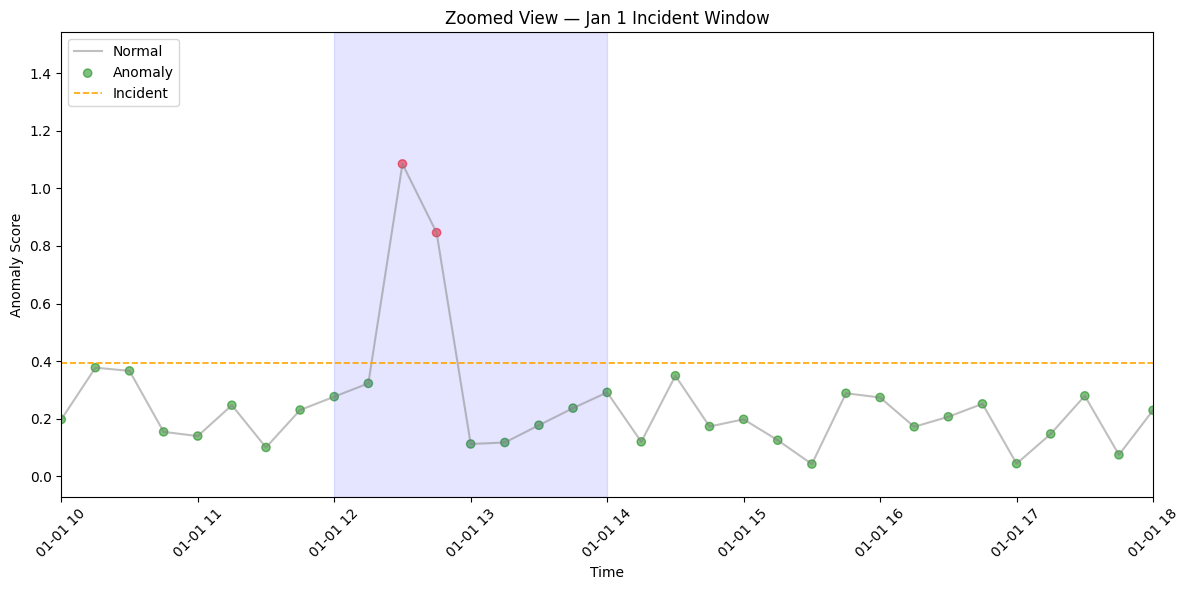

In [5]:
viz.plot_static(
    zoom=True,
    zoom_date=['2025-01-01 10:00', '2025-01-01 18:00'],
    threshold=threshold,
    title='Zoomed View — Jan 1 Incident Window',
    xlabel='Time',
    ylabel='Anomaly Score',
    legend_labels=['Normal', 'Anomaly', 'Incident'],
)

---
## 4. `plot_dynamic()` — Interactive Chart (Plotly)

The interactive chart offers capabilities the static plot doesn't:

- **Hover**: see exact timestamp and score for any point
- **Zoom and pan**: select an area to zoom in, drag to scroll
- **Toggle series**: click legend entries to show/hide series
- **Incident annotations**: bands include the affected service name
- **Threshold line**: optional horizontal reference line

### When to use static vs dynamic

| Use case | Recommendation |
|----------|---------------|
| Initial exploration | Dynamic — zoom and quick inspection |
| PDF reports or presentations | Static — exports as image |
| Shared notebooks | Dynamic — interactive widgets preserved in HTML |
| Very large datasets (>10K points) | Static — Plotly can become slow |

In [6]:
viz.plot_dynamic(
    threshold=threshold,
    title='Anomaly Scores — Interactive View with Threshold',
    xaxis_title='Time',
    yaxis_title='Anomaly Score',
    colors={'normal': 'steelblue', 'anomaly': 'crimson', 'incident': 'orange'},
)

---
## 5. `plot_score_distribution()` — Score Histogram

This histogram splits anomaly scores by class (normal vs anomaly) and helps assess the **separation** between the two distributions.

### How to interpret

| Pattern | Meaning |
|---------|---------|
| Clear gap between blue and red | Good separation — detector can reliably distinguish anomalies |
| Heavy overlap | Poor separation — many borderline cases, threshold tuning is critical |
| Threshold line in the gap | Well-calibrated cutoff |
| Threshold line inside the overlap zone | Some misclassifications are inevitable |

The optional `threshold` parameter draws a vertical line showing where the cutoff falls relative to the two distributions.

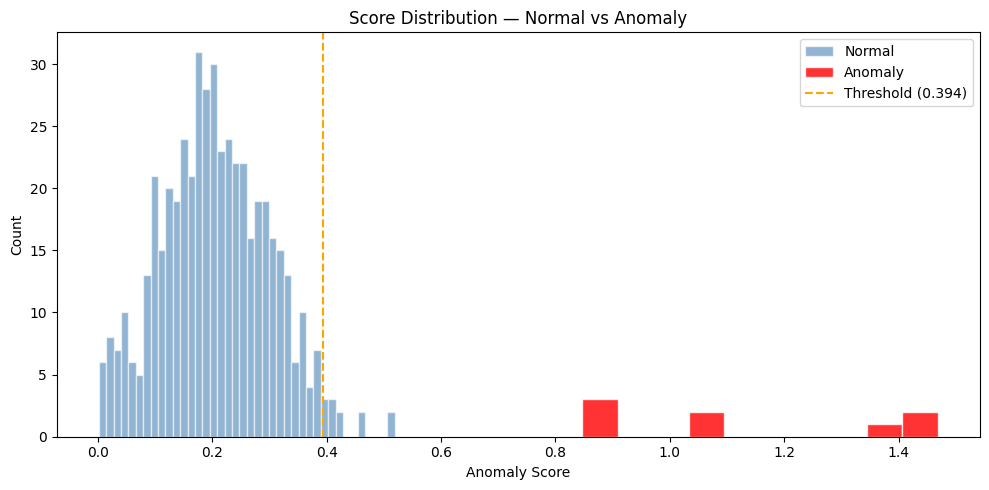

In [7]:
viz.plot_score_distribution(
    bins=40,
    threshold=threshold,
    title='Score Distribution — Normal vs Anomaly',
)

---
## 6. `plot_features()` — Feature Time Series with Anomaly Markers

While the score plot tells you *when* anomalies occurred, the feature plot tells you *what happened* in the underlying data. 
It shows each numeric feature as a time series with red markers overlaid on samples classified as anomalies.

### Use cases

- **Root cause analysis**: see which features spiked during an anomaly
- **Feature validation**: confirm that the features you engineered actually capture the anomalous behavior
- **Communication**: show stakeholders the raw data behind each detection

By default, all numeric columns (except `scores` and `anomaly`) are plotted. You can pass `feature_columns` to select specific ones.

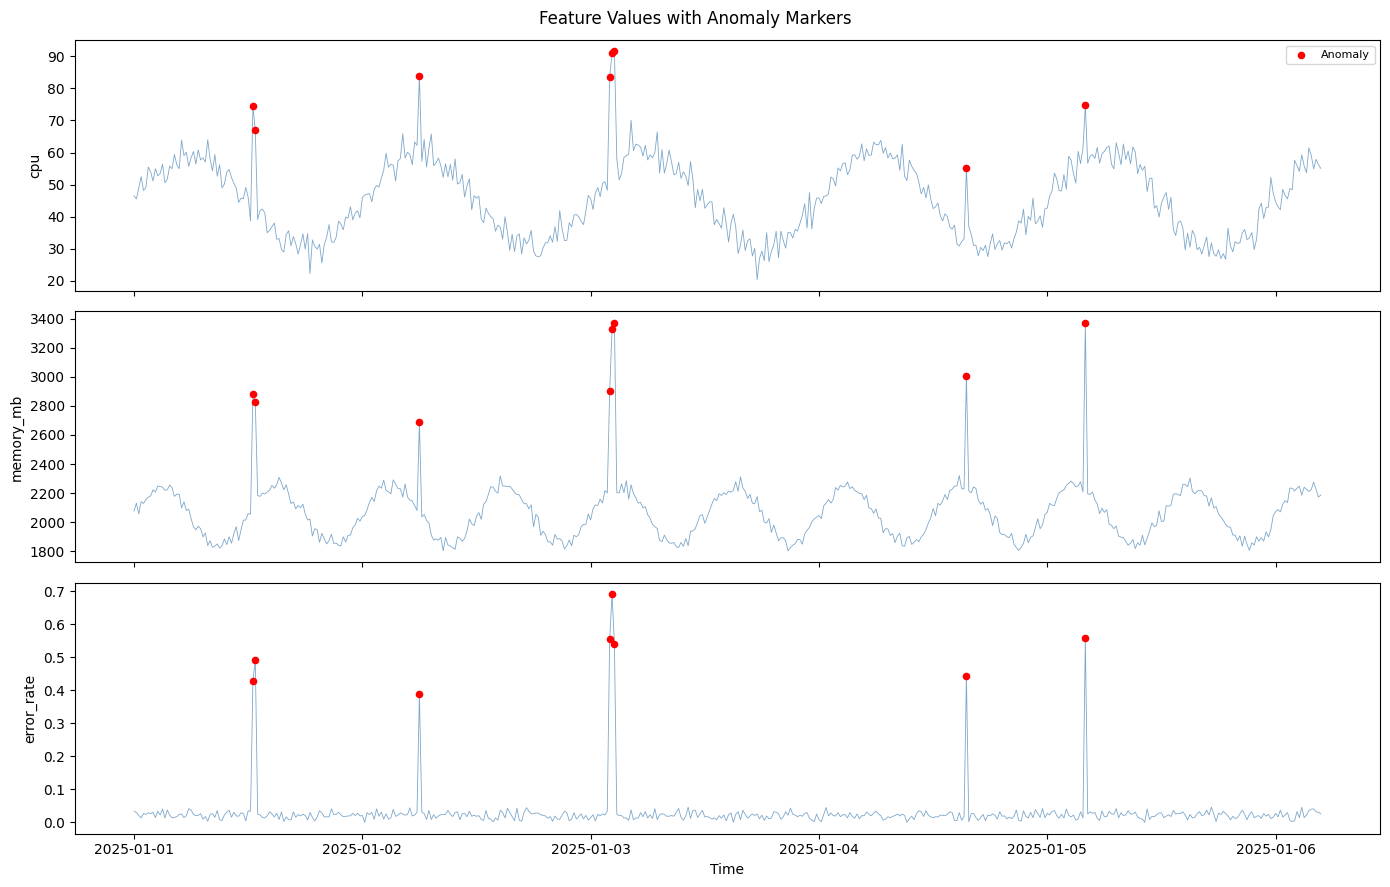

In [8]:
# Plot all features with anomaly markers
viz.plot_features(
    title='Feature Values with Anomaly Markers',
)

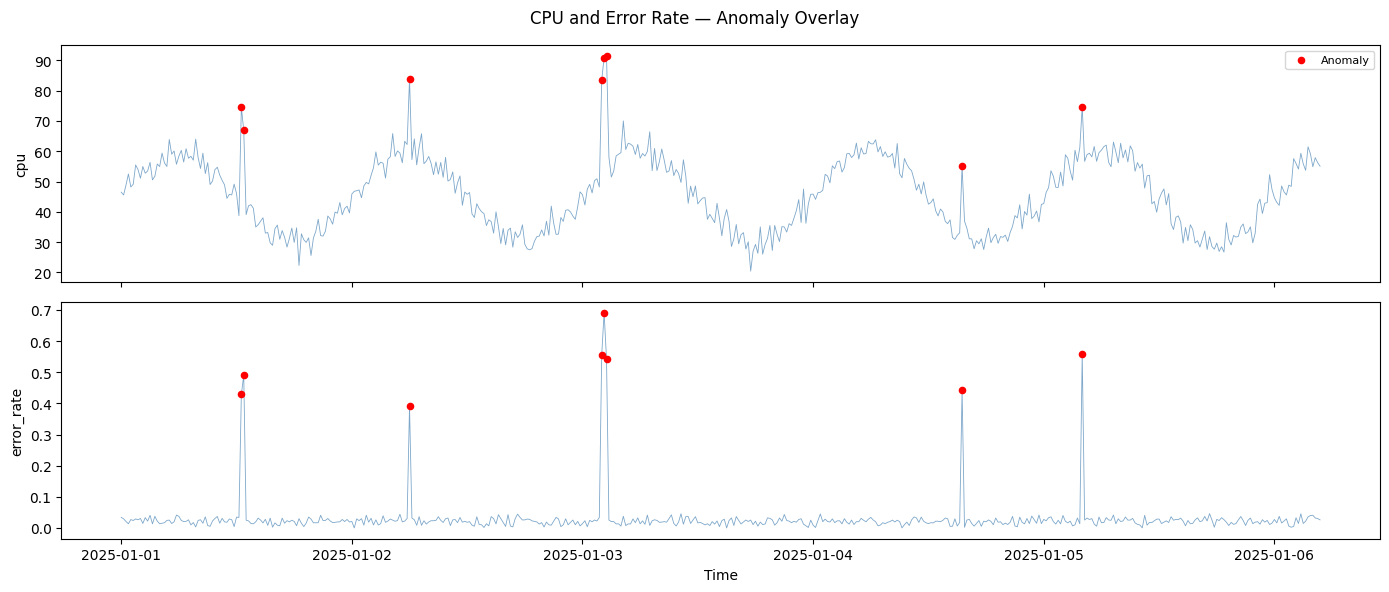

In [9]:
# Plot only selected features
viz.plot_features(
    feature_columns=['cpu', 'error_rate'],
    title='CPU and Error Rate — Anomaly Overlay',
)

---
## 7. AnomalyVisualizer without incidents

The `incidents_df` parameter is optional. In many real scenarios you don't have an incident log, or you're doing exploratory detection without ground truth. 
The visualizer works the same way, just without the overlaid bands.

This is useful when:
- Exploring a new dataset without labels
- Visualizing detector scores only, to calibrate thresholds
- Doing real-time monitoring without a historical incident registry

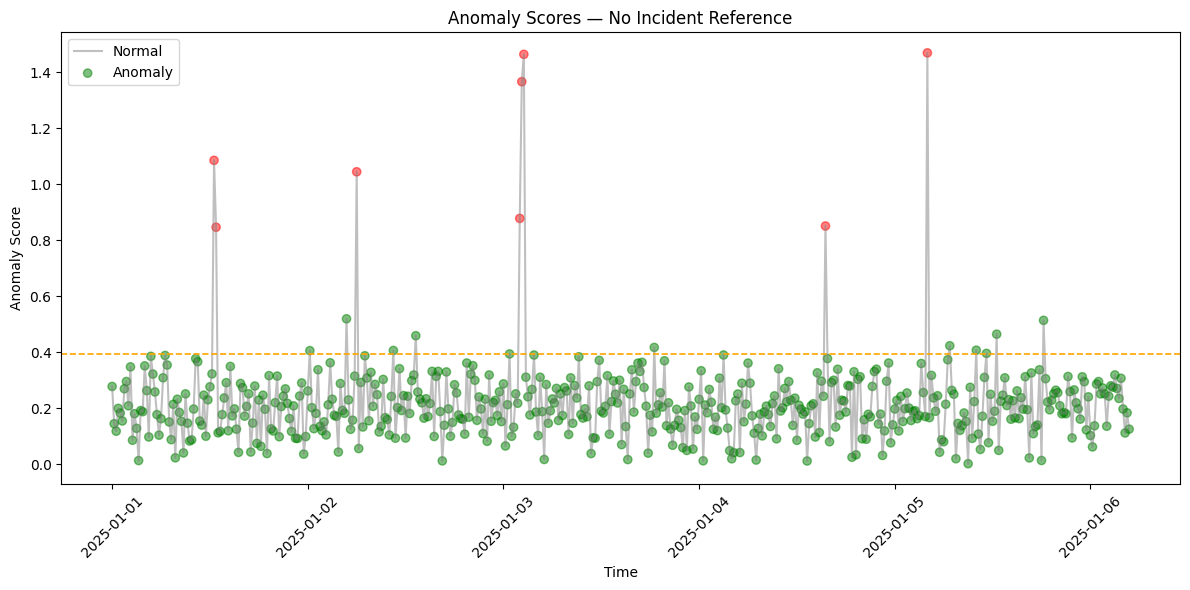

In [10]:
viz_no_incidents = AnomalyVisualizer(
    anomaly_df=anomaly_df,
    score_col='scores',
    anomaly_col='anomaly',
)

viz_no_incidents.plot_static(
    threshold=threshold,
    title='Anomaly Scores — No Incident Reference',
    xlabel='Time',
    ylabel='Anomaly Score',
    legend_labels=['Normal', 'Anomaly'],
)

---
## 8. SHAPVisualizer — Model Interpretability

Detecting anomalies is only half the job. The natural follow-up question is: **why is this sample anomalous?** 
Was it a CPU spike? An increase in error rate? A combination of factors?

`SHAPVisualizer` answers this using [SHAP (SHapley Additive exPlanations)](https://shap.readthedocs.io/), 
an interpretability framework based on game theory that decomposes each prediction into individual feature contributions.

### How SHAP works

1. For each sample, SHAP calculates how much each feature contributed to moving the prediction from the base value (average) to the final value
2. Positive contributions push toward "more anomalous"; negative contributions push toward "more normal"
3. The sum of all contributions + the base value = the model's final prediction

### Available methods

| Method | Scope | Best for |
|--------|-------|----------|
| `plot_force()` | Single sample | Detailed explanation of one prediction |
| `plot_waterfall()` | Single sample | Cleaner alternative to force plot with many features |
| `plot_summary()` | All samples | Global feature importance with value distributions |
| `plot_bar()` | All samples | Clean global importance ranking (no distribution detail) |
| `plot_dependence()` | One feature | Non-linear relationships and feature interactions |

### Limitations

- `SHAPVisualizer` currently supports tree-based models (`IsolationForestDetector`) via `TreeExplainer`
- For deep learning detectors (`AutoencoderDetector`, `LNNDetector`), `DeepExplainer` or `GradientExplainer` would be needed (not yet implemented)

### Data preparation

We create a multivariate dataset with 4 named features and inject known anomalies so we can verify SHAP identifies the correct features.

In [11]:
from sentinel.detectors import IsolationForestDetector
from sentinel.visualization import SHAPVisualizer

# Create multivariate data with named features
n_rows = 300
feature_data = pd.DataFrame({
    'cpu_usage': np.random.normal(50, 10, n_rows),
    'memory_mb': np.random.normal(2048, 256, n_rows),
    'request_count': np.random.poisson(100, n_rows).astype(float),
    'error_rate': np.abs(np.random.normal(0.02, 0.01, n_rows)),
})

# Inject known anomalies in specific features
feature_data.loc[10, 'cpu_usage'] = 99       # CPU spike
feature_data.loc[10, 'error_rate'] = 0.5      # Error rate spike (same sample)
feature_data.loc[50, 'memory_mb'] = 8000      # Memory spike
feature_data.loc[150, 'request_count'] = 500  # Request spike

# Train detector
iso_detector = IsolationForestDetector(contamination=0.05, random_state=42)
iso_detector.fit(feature_data)
predictions = iso_detector.predict(feature_data)

anomaly_idx = np.where(predictions == -1)[0]
print(f"Detected {len(anomaly_idx)} anomalies")
print(f"Indices: {anomaly_idx.tolist()}")

Detected 15 anomalies
Indices: [0, 10, 11, 50, 94, 96, 140, 150, 182, 204, 220, 234, 247, 266, 281]


/Users/jomaver/Desktop/Code/sentinel/.venv/lib/python3.12/site-packages/rrcf/__init__.py:3: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


---
### 8.1 `plot_force()` — Single Sample Explanation

The force plot shows the explanation for a single prediction:

- The **base value** is the model's average prediction across the entire dataset
- **Red arrows**: features pushing toward "more anomalous"
- **Blue arrows**: features pushing toward "more normal"
- Arrow **width** is proportional to the contribution magnitude
- The **output value** is the model's final prediction for that sample

Since we injected `cpu_usage=99` and `error_rate=0.5` at index 10, we expect SHAP to assign large red contributions to those two features.

Explaining anomaly at index 0:
cpu_usage          19.804878
memory_mb        2046.567419
request_count      87.000000
error_rate          0.042817
Name: 0, dtype: float64



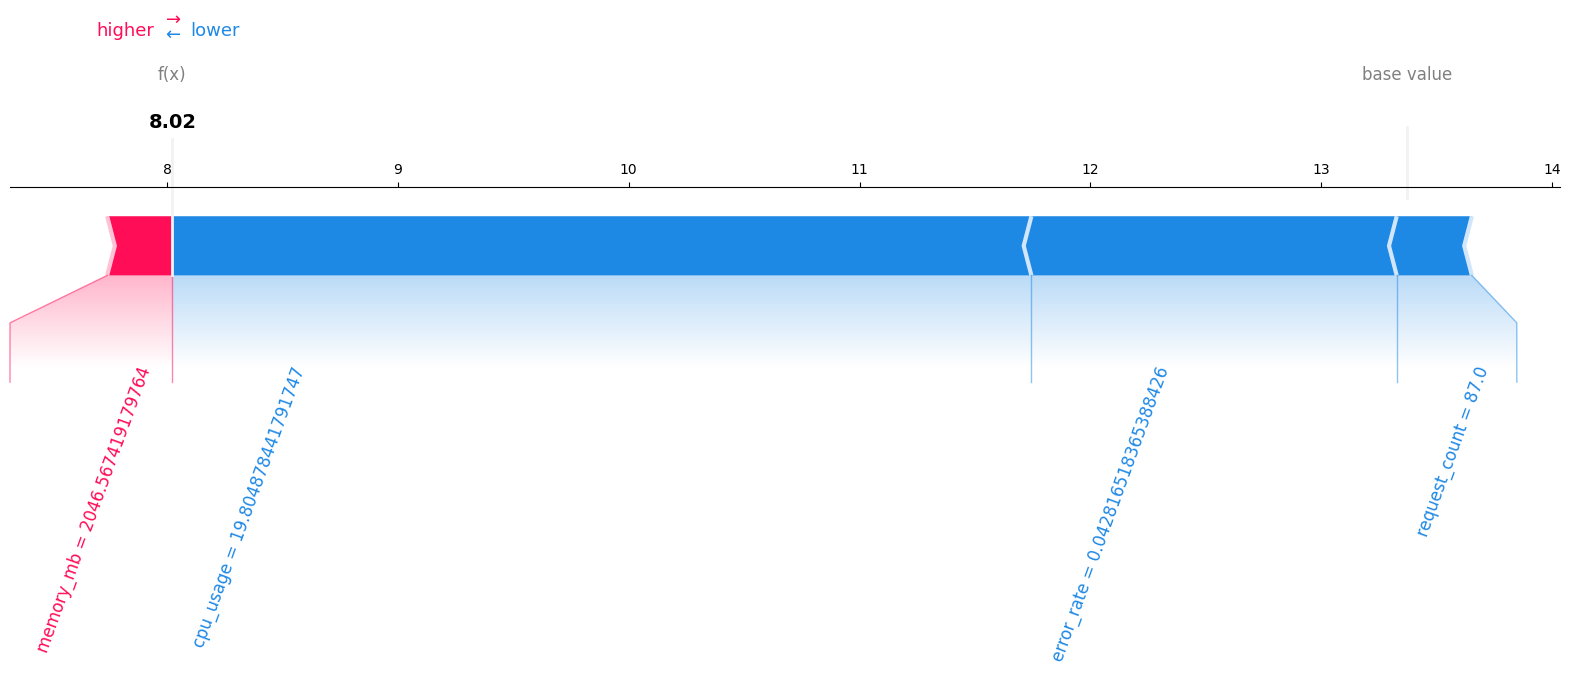

In [12]:
shap_viz = SHAPVisualizer(iso_detector)

# Explain the first detected anomaly
if len(anomaly_idx) > 0:
    idx = anomaly_idx[0]
    print(f"Explaining anomaly at index {idx}:")
    print(feature_data.iloc[idx])
    print()
    shap_viz.plot_force(feature_data, anomaly_index=idx)
else:
    print("No anomalies detected to explain.")

---
### 8.2 `plot_waterfall()` — Waterfall Chart (Single Sample)

The waterfall chart is a cleaner alternative to the force plot, especially when there are many features. 
It shows each feature's contribution as a stacked vertical bar chart, starting from the base value and building up to the final prediction.

### How to read it

- Each bar represents one feature's SHAP value
- Red bars push the prediction toward anomaly (positive contribution)
- Blue bars push toward normal (negative contribution)
- The bars stack from the base value (E[f(x)]) to the final output f(x)
- Feature values are shown on the left axis for context

Waterfall chart for sample 0:


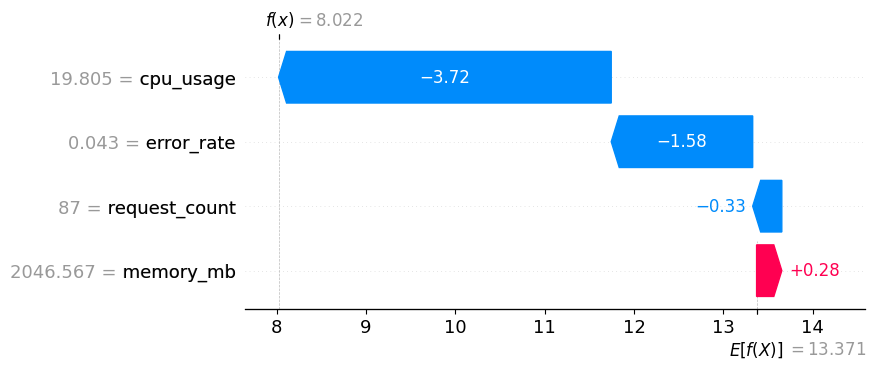

In [13]:
if len(anomaly_idx) > 0:
    idx = anomaly_idx[0]
    print(f"Waterfall chart for sample {idx}:")
    shap_viz.plot_waterfall(feature_data, sample_index=idx)

---
### 8.3 `plot_summary()` — Global Feature Importance (Beeswarm)

The summary (beeswarm) plot shows the big picture across all samples:

- Each **dot** represents one sample
- **X axis**: SHAP value (impact on prediction)
- **Color**: feature value (red = high, blue = low)
- Features sorted top to bottom by **importance** (highest average impact first)

| Visual pattern | Interpretation |
|---------------|----------------|
| Red dots on the right | High values of that feature push toward anomaly |
| Blue dots on the right | Low values push toward anomaly |
| Wide spread | High impact feature |
| Dots concentrated at 0 | Low impact feature |

/Users/jomaver/Desktop/Code/sentinel/src/sentinel/visualization/visualization.py:298: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X)


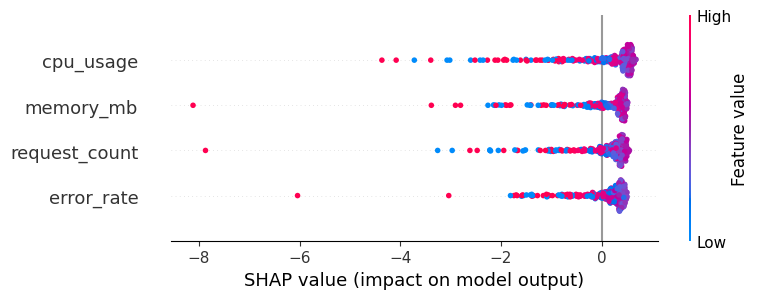

In [14]:
shap_viz.plot_summary(feature_data)

---
### 8.4 `plot_bar()` — Global Feature Importance (Bar Chart)

The bar chart shows the mean absolute SHAP value per feature as horizontal bars. 
It provides a cleaner view than the summary plot when you only need the importance ranking without the distribution detail.

This is the go-to chart for presentations and reports where you need to quickly communicate which features matter most.

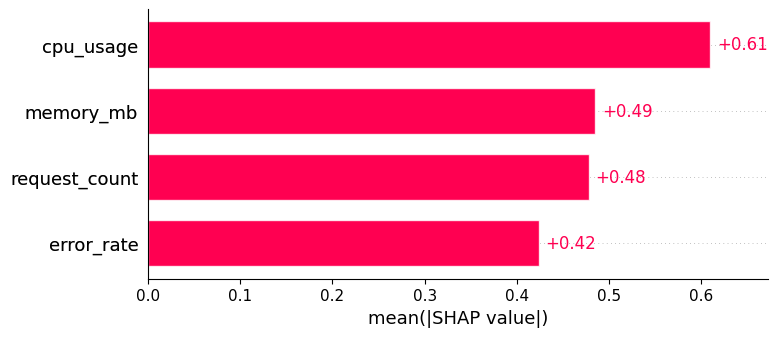

In [15]:
shap_viz.plot_bar(feature_data)

---
### 8.5 `plot_dependence()` — Feature Dependence Scatter

The dependence plot reveals **non-linear relationships** between a feature's value and its impact on the prediction. 
Each dot is one sample, with the feature value on the X axis and its SHAP value on the Y axis.

### What to look for

- **Flat line at SHAP=0**: the feature has no impact regardless of its value
- **Step function**: the feature only matters above/below a certain threshold (e.g., "CPU only matters when it exceeds 80%")
- **Colored by interaction feature**: reveals how two features interact (e.g., high CPU matters more when memory is also high)

If `interaction_feature` is `None`, SHAP automatically picks the strongest interaction.

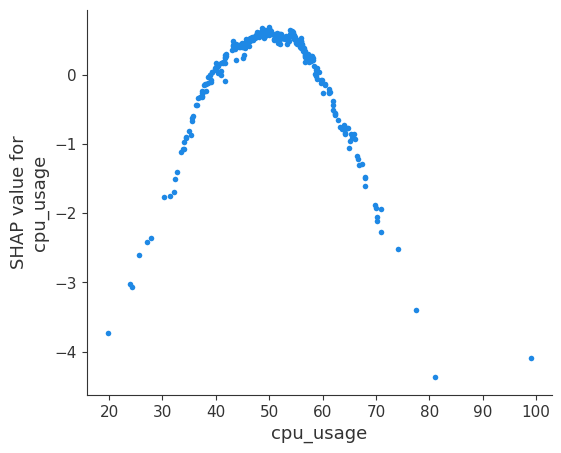

In [16]:
# Dependence plot for cpu_usage, colored by strongest interaction
shap_viz.plot_dependence(feature_data, feature='cpu_usage')

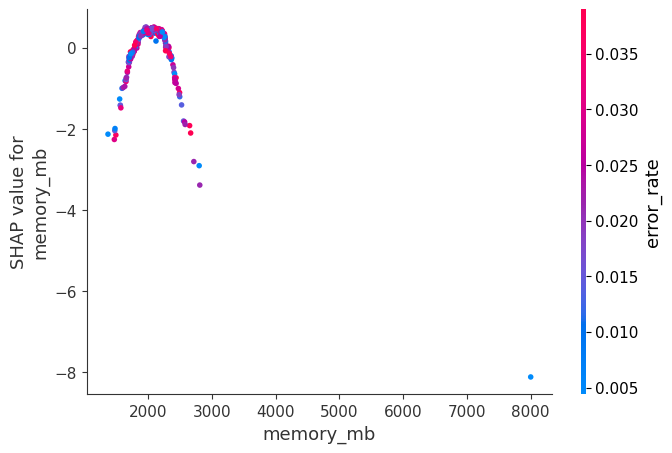

In [17]:
# Dependence plot for memory_mb, colored by error_rate interaction
shap_viz.plot_dependence(feature_data, feature='memory_mb', interaction_feature='error_rate')

---
## Summary

| Tool | Method | Primary use |
|------|--------|-------------|
| `AnomalyVisualizer` | `plot_static()` | Score timeline with matplotlib — ideal for reports |
| `AnomalyVisualizer` | `plot_dynamic()` | Interactive chart with Plotly — ideal for exploration |
| `AnomalyVisualizer` | `plot_score_distribution()` | Score histogram — assess class separation and threshold calibration |
| `AnomalyVisualizer` | `plot_features()` | Feature time series — root cause analysis |
| `SHAPVisualizer` | `plot_force()` | Single sample explanation — detailed feature contributions |
| `SHAPVisualizer` | `plot_waterfall()` | Single sample explanation — cleaner stacked bar format |
| `SHAPVisualizer` | `plot_summary()` | Global beeswarm — feature importance with distributions |
| `SHAPVisualizer` | `plot_bar()` | Global bar chart — clean importance ranking |
| `SHAPVisualizer` | `plot_dependence()` | Feature dependence — non-linear relationships and interactions |

### Practical tips

- Use `incidents_df` whenever you have incident logs — the visual correlation between detected anomalies and real incidents is the most direct way to evaluate a detector
- The `threshold` parameter in `plot_static()` and `plot_dynamic()` helps calibrate the cutoff visually
- `plot_score_distribution()` is the fastest way to assess whether your threshold is well-placed
- `plot_features()` is essential for root cause analysis — it shows *what happened* in the data when an anomaly was detected
- SHAP is computationally expensive on large datasets — consider using a representative subset for the summary plot
- Use `plot_bar()` for presentations and `plot_summary()` for deeper analysis
- `plot_dependence()` is most useful when you suspect non-linear feature effects or interactions